<a href="https://colab.research.google.com/github/Deeparam06-devcodes/Deeparepo/blob/main/GreenCity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print("Task 1 - TensorFlow version:", tf.__version__)

import os
print(os.listdir('/content'))

!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("techsash/waste-classification-data")
print("Dataset path:", path)

Task 1 - TensorFlow version: 2.20.0
['.config', 'sample_data']
Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset path: /kaggle/input/waste-classification-data


In [2]:
import os

print(os.listdir(path))

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)
    print("\n", folder)
    print(os.listdir(full_path))

train_path = os.path.join(path, 'DATASET', 'TRAIN')
test_path = os.path.join(path, 'DATASET', 'TEST')

print("TRAIN:", os.listdir(train_path))
print("TEST:", os.listdir(test_path))

['DATASET', 'dataset']

 DATASET
['TEST', 'TRAIN']

 dataset
['DATASET']
TRAIN: ['R', 'O']
TEST: ['R', 'O']


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Task 2 - test_generator created")
print("Task 3 - Number of training batches:", len(train_generator))

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Task 2 - test_generator created
Task 3 - Number of training batches: 706


In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

extract_feat_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

print("Task 4 - Extract Features Model Summary")
extract_feat_model.summary()

extract_feat_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Task 5 - Extract Features Model compiled")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Task 4 - Extract Features Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Task 5 - Extract Features Model compiled


In [5]:
history_extract = extract_feat_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=1,
    steps_per_epoch=min(20, len(train_generator)),
    validation_steps=min(5, len(test_generator))
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 496s 25s/step - accuracy: 0.6609 - loss: 0.9828 - val_accuracy: 0.9438 - val_loss: 0.2656


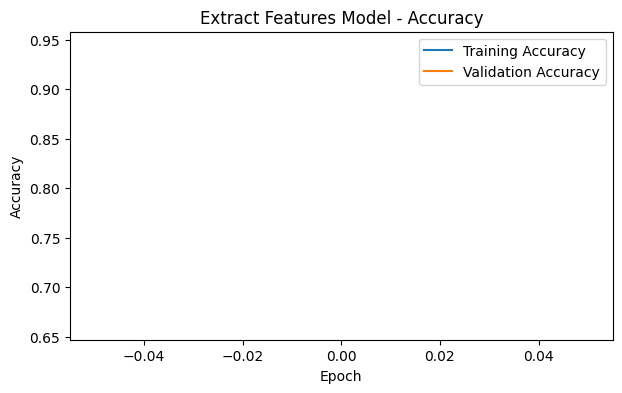

In [6]:
import matplotlib.pyplot as plt

# Task 6 - Accuracy curves for extract_feat_model
plt.figure(figsize=(7, 4))
plt.plot(history_extract.history['accuracy'], label='Training Accuracy')
plt.plot(history_extract.history['val_accuracy'], label='Validation Accuracy')
plt.title('Extract Features Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

fine_tune_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history_fine = fine_tune_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=1,
    steps_per_epoch=3,
    validation_steps=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 95s 34s/step - accuracy: 0.5312 - loss: 0.8733 - val_accuracy: 0.2500 - val_loss: 0.8717


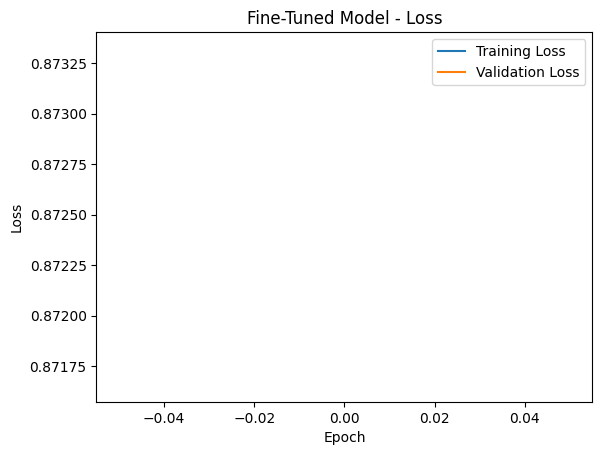

In [10]:
plt.plot(history_fine.history['loss'], label='Training Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')

plt.title('Fine-Tuned Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

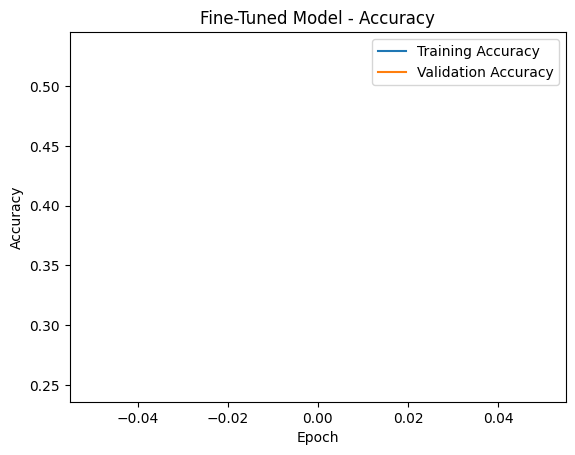

In [11]:
plt.plot(history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy')

plt.title('Fine-Tuned Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

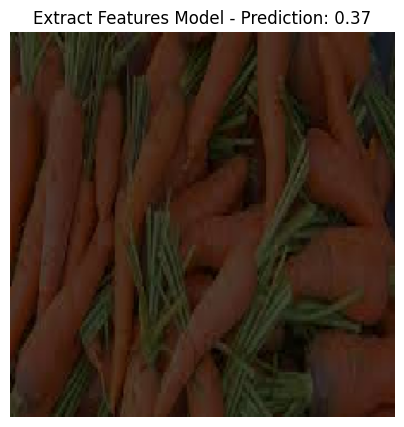

In [12]:
import numpy as np

index_to_plot = 1

images, labels = test_generator[index_to_plot]
image = images[0]

prediction = extract_feat_model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)[0][0]

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f'Extract Features Model - Prediction: {prediction:.2f}')
plt.axis('off')
plt.show()

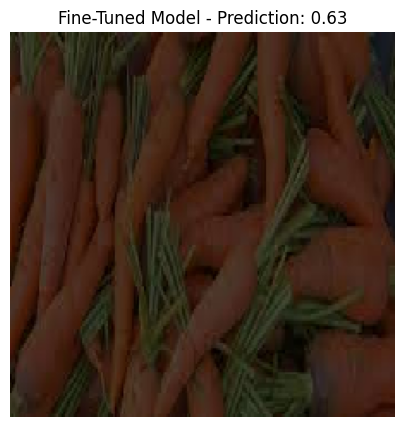

In [13]:
index_to_plot = 1

images, labels = test_generator[index_to_plot]
image = images[0]

prediction = fine_tune_model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)[0][0]

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f'Fine-Tuned Model - Prediction: {prediction:.2f}')
plt.axis('off')
plt.show()